In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection
import train_test_split
from sklearn.linear_model import LinearRegression
import joblib
from sklearn.metrics import mean_squared_error, r2_score
import os
if 'data' not in os.listdir():
    os.mkdir('data')
if 'raw' not in os.listdir('data/'):
    os.mkdir('data/raw')
if 'processed' not in os.listdir('data/'):
    os.mkdir('data/processed')


In [14]:

year_data_mapping = {
    '2011-2012': 'G',
    '2013-2014': 'H',
}

def load_nhanes_file(year, letter, file_prefix):
    # diff format for two years but let's use old ones bc more data
    if year in ['2011-2012', '2013-2014']:
        # before 2017
        start_year = year.split('-')[0]
        url = f'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{start_year}/DataFiles/{file_prefix}_{letter}.xpt'
    else:
        # after 2017
        url = f'https://wwwn.cdc.gov/Nchs/Nhanes/{year}/{file_prefix}_{letter}.XPT'
    
    return pd.read_sas(url, format='xport')

data_sources = {
    year: {
        'demographic': load_nhanes_file(year, letter, 'DEMO'),
        'bp_cholesterol': load_nhanes_file(year, letter, 'BPQ'),
        'cardiovascular': load_nhanes_file(year, letter, 'CDQ'),
        'cognitive': load_nhanes_file(year, letter, 'CFQ'),
        'diabetes': load_nhanes_file(year, letter, 'DIQ'),
        'diet_nutrition': load_nhanes_file(year, letter, 'DBQ'),
        'housing': load_nhanes_file(year, letter, 'HOQ'),
        'income': load_nhanes_file(year, letter, 'INQ'),
        'mental_health': load_nhanes_file(year, letter, 'DPQ'),
        'physical_activity': load_nhanes_file(year, letter, 'PAQ'),
        'sleep_disorder': load_nhanes_file(year, letter, 'SLQ'),
        'cigarette_use': load_nhanes_file(year, letter, 'SMQ'),
        # Added data sources
        'alcohol_use': load_nhanes_file(year, letter, 'ALQ'),
        'medical_conditions': load_nhanes_file(year, letter, 'MCQ'),
        'access_to_care': load_nhanes_file(year, letter, 'HUQ'),
        'food_security': load_nhanes_file(year, letter, 'FSQ'),
        'immunization': load_nhanes_file(year, letter, 'IMQ'),
        'weight_history': load_nhanes_file(year, letter, 'WHQ'),
        'weight_history_youth': load_nhanes_file(year, letter, 'WHQMEC'),
        'drug_use': load_nhanes_file(year, letter, 'DUQ'),
        'occupation': load_nhanes_file(year, letter, 'OCQ'),
        'prescription_medication': load_nhanes_file(year, letter, 'RXQ_RX')

    }
    for year, letter in year_data_mapping.items()
}


In [15]:
#to keep track of the columns shared b/t the two years
column_tracker = {
    file: []
    for file in data_sources['2011-2012']
}

In [16]:
for year, data in data_sources.items():
    for file in column_tracker:

        if len(column_tracker[file]) == 0:
            column_tracker[file] = data[file].columns
        else:
            column_tracker[file] = [
                col
                for col in data[file].columns
                if col in column_tracker[file]
            ]

In [17]:

# Save dataframes to data/raw directory
for year, data in data_sources.items():
    for file, df in data.items():
        df[column_tracker[file]].to_csv(
            'data/raw/{}_{}.csv'.format(year, file),
            index = False
        )

In [18]:
annual_merged_data = {
    '2011-2012': pd.read_csv('data/raw/2011-2012_cognitive.csv'), 
    '2013-2014': pd.read_csv('data/raw/2013-2014_cognitive.csv')
}


In [19]:
for file in os.listdir('data/raw/'):
    year = file.split('_')[0]
    questionnaire = file.split('_')[1]
    if year not in annual_merged_data or questionnaire == 'cognitive.csv':
        continue
    data_snippet_df = pd.read_csv(f'data/raw/{file}')
    annual_merged_data[year] = annual_merged_data[year].merge(data_snippet_df, how = 'left', on = 'SEQN')

merged_nhanes_df = pd.concat(annual_merged_data.values(), axis=0)
merged_nhanes_df

#cognitive data here

merged_nhanes_df = merged_nhanes_df[merged_nhanes_df['CFDCCS'] == 1] #CERAD Completion Status (Gets rid of ppl who didn't complete all 4 recalls). 
merged_nhanes_df = merged_nhanes_df[merged_nhanes_df['CFDCST1'].notna()] #CERAD Score Trial 1
merged_nhanes_df = merged_nhanes_df[merged_nhanes_df['CFDCSR'].notna()] #CERAD Score Delayed Recall
merged_nhanes_df = merged_nhanes_df[merged_nhanes_df['CFDDS'].notna()]  #Digit Symbol Score
merged_nhanes_df = merged_nhanes_df[merged_nhanes_df['CFDAST'].notna()] #Animal Fluency Score Total



In [20]:
prop_missing = merged_nhanes_df.isnull().sum() / len(merged_nhanes_df)
merged_nhanes_df = merged_nhanes_df[merged_nhanes_df.columns[(prop_missing < 0.1)]]

In [23]:
merged_nhanes_df.to_csv('data/processed/merged_nhanes.csv', index=False)

In [24]:
import pandas as pd
import numpy as np
import os

from scipy.stats import zscore 
from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

from sklearn.decomposition import PCA 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder 
from sklearn.preprocessing import StandardScaler 

from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import PrecisionRecallDisplay
import xgboost as xgb
from sklearn.tree import DecisionTreeClassifier


from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_auc_score 
from sklearn import metrics
from sklearn.inspection import permutation_importance

import joblib
import pickle


In [25]:
merged_nhanes_df = pd.read_csv('data/processed/merged_nhanes.csv')


In [26]:
merged_nhanes_df['CFDCST1'] = zscore(merged_nhanes_df['CFDCST1'])
merged_nhanes_df['CFDCSR'] = zscore(merged_nhanes_df['CFDCSR'])
merged_nhanes_df['CFDDS'] = zscore(merged_nhanes_df['CFDDS'])
merged_nhanes_df['CFDAST'] = zscore(merged_nhanes_df['CFDAST'])

In [27]:
merged_nhanes_df['cognitive_decline_label'] = merged_nhanes_df[['CFDCST1', 'CFDCSR','CFDDS', 'CFDAST']].mean(axis = 1)
merged_nhanes_df['cognitive_decline_label'] = merged_nhanes_df['cognitive_decline_label'] < merged_nhanes_df['cognitive_decline_label'].quantile(0.1)
merged_nhanes_df

,SEQN,CFASTAT,CFALANG,CFDCCS,CFDCST1,CFDCST2,CFDCST3,CFDCSR,CFDCIT1,CFDCIT2,...,WHD020,WHQ030,WHQ040,WHD050,WHD110,WHD120,WHD130,WHD140,WHQ150,cognitive_decline_label
0,62174.0,1.0,1.0,1.0,-0.926351,6.0,7.0,-0.288461,5.397605e-79,5.397605e-79,...,211.0,1.0,2.0,220.0,221.0,160.0,69.0,222.0,70.0,False
1,62174.0,1.0,1.0,1.0,-0.926351,6.0,7.0,-0.288461,5.397605e-79,5.397605e-79,...,211.0,1.0,2.0,220.0,221.0,160.0,69.0,222.0,70.0,False
2,62174.0,1.0,1.0,1.0,-0.926351,6.0,7.0,-0.288461,5.397605e-79,5.397605e-79,...,211.0,1.0,2.0,220.0,221.0,160.0,69.0,222.0,70.0,False
3,62174.0,1.0,1.0,1.0,-0.926351,6.0,7.0,-0.288461,5.397605e-79,5.397605e-79,...,211.0,1.0,2.0,220.0,221.0,160.0,69.0,222.0,70.0,False
4,62174.0,1.0,1.0,1.0,-0.926351,6.0,7.0,-0.288461,5.397605e-79,5.397605e-79,...,211.0,1.0,2.0,220.0,221.0,160.0,69.0,222.0,70.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11999,83724.0,1.0,1.0,1.0,-0.926351,6.0,6.0,-0.288461,5.397605e-79,1.000000e+00,...,173.0,3.0,3.0,173.0,173.0,140.0,71.0,190.0,55.0,False
12000,83724.0,1.0,1.0,1.0,-0.926351,6.0,6.0,-0.288461,5.397605e-79,1.000000e+00,...,173.0,3.0,3.0,173.0,173.0,140.0,71.0,190.0,55.0,False
12001,83724.0,1.0,1.0,1.0,-0.926351,6.0,6.0,-0.288461,5.397605e-79,1.000000e+00,...,173.0,3.0,3.0,173.0,173.0,140.0,71.0,190.0,55.0,False
12002,83724.0,1.0,1.0,1.0,-0.926351,6.0,6.0,-0.288461,5.397605e-79,1.000000e+00,...,173.0,3.0,3.0,173.0,173.0,140.0,71.0,190.0,55.0,False


In [28]:
#making sure that theres true and false values
merged_nhanes_df['cognitive_decline_label'].value_counts()

cognitive_decline_label
False    10807
True      1197
Name: count, dtype: int64

In [29]:
[x for x in merged_nhanes_df.columns]

['SEQN',
 'CFASTAT',
 'CFALANG',
 'CFDCCS',
 'CFDCST1',
 'CFDCST2',
 'CFDCST3',
 'CFDCSR',
 'CFDCIT1',
 'CFDCIT2',
 'CFDCIT3',
 'CFDCIR',
 'CFDAPP',
 'CFDAST',
 'CFDDPP',
 'CFDDS',
 'HUQ010',
 'HUQ020',
 'HUQ030',
 'HUQ071',
 'HUQ090',
 'ALQ101',
 'BPQ020',
 'BPQ056',
 'BPQ059',
 'BPQ080',
 'BPQ070',
 'BPQ090D',
 'CDQ001',
 'CDQ010',
 'SMQ020',
 'SMDUPCA',
 'SMD100BR',
 'SMAQUEX2',
 'SDDSRVYR',
 'RIDSTATR',
 'RIAGENDR',
 'RIDAGEYR',
 'RIDRETH1',
 'RIDRETH3',
 'RIDEXMON',
 'DMQMILIZ',
 'DMDBORN4',
 'DMDCITZN',
 'DMDEDUC2',
 'DMDMARTL',
 'SIALANG',
 'SIAPROXY',
 'SIAINTRP',
 'FIALANG',
 'FIAPROXY',
 'FIAINTRP',
 'MIALANG',
 'MIAPROXY',
 'MIAINTRP',
 'DMDHHSIZ',
 'DMDFMSIZ',
 'DMDHHSZA',
 'DMDHHSZB',
 'DMDHHSZE',
 'DMDHRGND',
 'DMDHRAGE',
 'DMDHRBR4',
 'DMDHREDU',
 'DMDHRMAR',
 'WTINT2YR',
 'WTMEC2YR',
 'SDMVPSU',
 'SDMVSTRA',
 'INDHHIN2',
 'INDFMIN2',
 'INDFMPIR',
 'DIQ010',
 'DIQ050',
 'DBQ700',
 'DBQ197',
 'DBQ229',
 'DBQ301',
 'DBQ330',
 'DBD895',
 'DBD905',
 'DBD910',
 'FSD032A',
 'F

In [30]:
label = ['cognitive_decline_label']
features = ['MCQ053', 'SLQ060', 'RIAGENDR', 'RIDAGEYR', 
            'RIDRETH3', 'INDHHIN2', 'BPQ020','BPQ080', 
            'DIQ010', 'PAD680', 'CDQ001', 'DPQ020', 
            'MCQ080', 'MCQ084', 'MCQ140', 'MCQ160c', 
            'MCQ160f', 'MCQ220', 'HUQ050', 'DUQ272', 
            'DBQ700']
discluded_features = [x for x in features if x not in merged_nhanes_df.columns]
features = [x for x in features if x in merged_nhanes_df.columns]
len(features)

16

In [31]:
for feature in features:
    merged_nhanes_df[feature] = np.floor(merged_nhanes_df[feature]).astype('Int64')

In [32]:
y = merged_nhanes_df[label].values.ravel() #make 1d
X = merged_nhanes_df[features]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.columns

Index(['MCQ053', 'SLQ060', 'RIAGENDR', 'RIDAGEYR', 'RIDRETH3', 'INDHHIN2',
       'BPQ020', 'BPQ080', 'DIQ010', 'PAD680', 'CDQ001', 'DPQ020', 'MCQ080',
       'MCQ084', 'MCQ220', 'DBQ700'],
      dtype='object')

In [33]:
pickle.dump(X_train, open('data/processed/X_train.sav', 'wb'))
pickle.dump(X_test, open('data/processed/X_test.sav', 'wb'))
pickle.dump(y_train, open('data/processed/y_train.sav', 'wb'))
pickle.dump(y_test, open('data/processed/y_test.sav', 'wb'))

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('enc', OneHotEncoder(handle_unknown='ignore')),
    ('clf', LogisticRegression(max_iter=1000))
])
lr_pipe.fit(X_train, y_train)
lr_pred = lr_pipe.predict(X_test)
accuracy = accuracy_score(y_test, lr_pred)
print(f'Accuracy: {accuracy}')
joblib.dump(lr_pipe, 'models/logistic_regression_pipeline.sav')



Accuracy: 0.9179508538109121


['models/logistic_regression_pipeline.sav']

              precision    recall  f1-score   support

       False       0.92      0.99      0.96      2188
        True       0.64      0.17      0.27       213

    accuracy                           0.92      2401
   macro avg       0.78      0.58      0.61      2401
weighted avg       0.90      0.92      0.90      2401



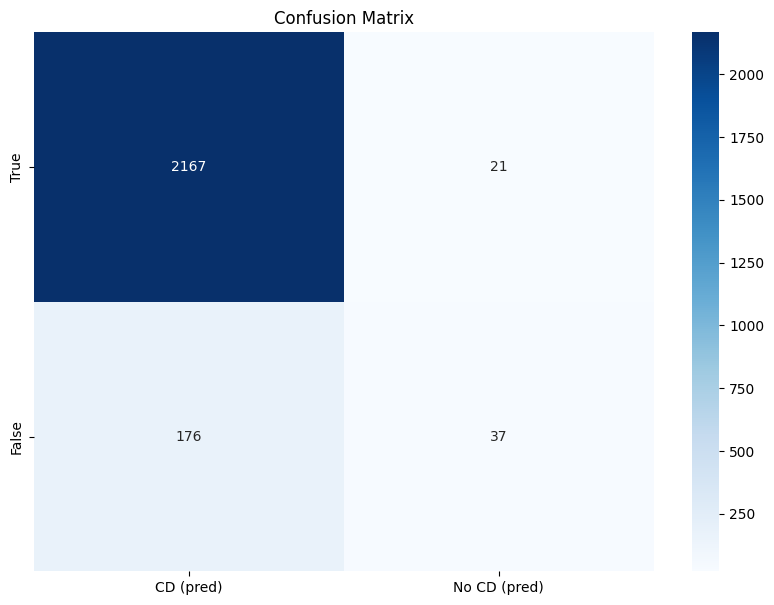

In [190]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#CM
lr_cm = confusion_matrix(y_test, lr_pred)
lr_cm_df = pd.DataFrame(
    lr_cm, 
    index=['True', 'False'],
    columns=['CD (pred)', 'No CD (pred)']
)
print(metrics.classification_report(y_test, lr_pred))
plt.figure(figsize=(10,7))
sns.heatmap(lr_cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


              precision    recall  f1-score   support

       False       0.99      1.00      0.99      2188
        True       0.99      0.85      0.92       213

    accuracy                           0.99      2401
   macro avg       0.99      0.93      0.96      2401
weighted avg       0.99      0.99      0.99      2401

0.9998671162312042
0.9723828056193821
0.008210242230468087
Accuracy: 0.9866722199083715


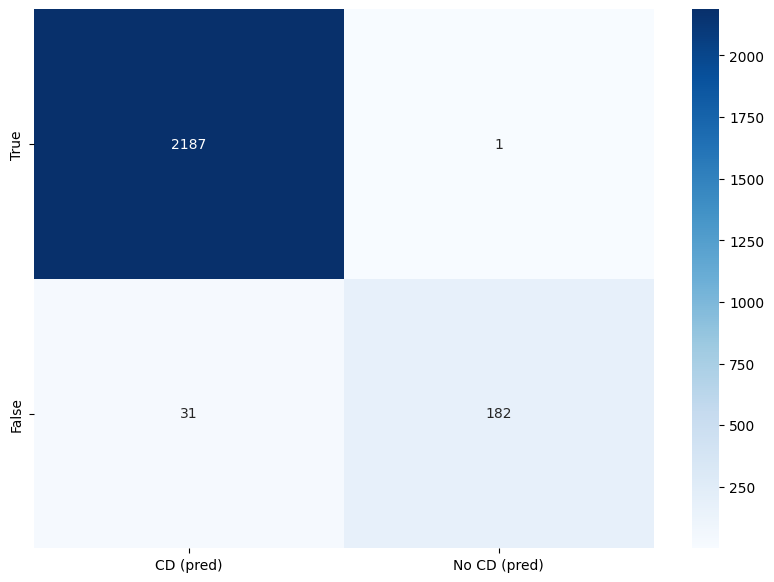

In [185]:
knn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('enc', OneHotEncoder(handle_unknown='ignore')),
    ('clf', KNeighborsClassifier(n_neighbors=2))
])
knn_pipe.fit(X_train, y_train)
knn_training_score = roc_auc_score(y_train, knn_pipe.predict_proba(X_train)[:, 1])
knn_scores = cross_validate(knn_pipe, X_train, y_train, cv=5, scoring='roc_auc')
knn_predicts = knn_pipe.predict(X_test)
print(metrics.classification_report(y_test, knn_predicts))

joblib.dump(knn_pipe, 'models/k_nearest_neighbors_pipeline.sav')

print(knn_training_score)
print(knn_scores['test_score'].mean())
print(knn_scores['test_score'].std())

accuracy = accuracy_score(y_test, knn_predicts)
print(f'Accuracy: {accuracy}')
# the confusion matrix for the rf model
knn_cm = confusion_matrix(y_test, knn_predicts)
knn_cm_df = pd.DataFrame(
    knn_cm, 
    index=['True', 'False'],
    columns=['CD (pred)', 'No CD (pred)']
)
plt.figure(figsize=(10, 7))
sns.heatmap(knn_cm_df, annot=True, fmt='d', cmap='Blues')
plt.show()



In [187]:
import numpy as np
import pandas as pd


feature_names = lr_pipe.named_steps['enc'].get_feature_names_out(input_features=X_train.columns)

coefficients = lr_pipe.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values(by='abs_coef', ascending=False)

print(coef_df[['feature', 'coefficient']].head(10))


           feature  coefficient
13   RIDAGEYR_65.0    -1.976144
64      PAD680_8.0     1.792198
53      BPQ020_9.0     1.785137
5       SLQ060_9.0     1.689127
92   PAD680_1080.0    -1.522282
69     PAD680_30.0     1.512244
28   RIDAGEYR_80.0     1.506777
97      CDQ001_9.0     1.489459
118     DBQ700_9.0     1.421054
12   RIDAGEYR_64.0    -1.321206


C:\Users\canlibstudent\AppData\Local\Temp\ipykernel_7888\1379554799.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coefficient', y='feature', data=top_coef, palette='coolwarm')


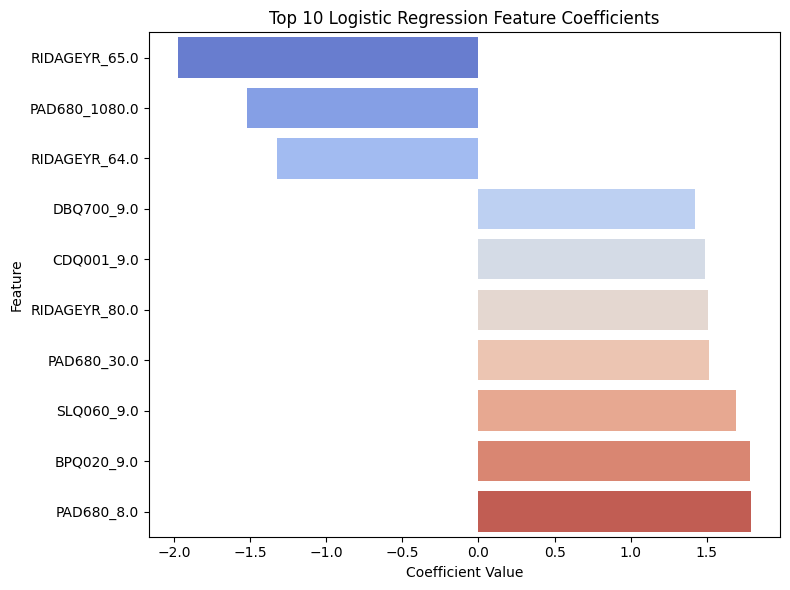

In [188]:
import matplotlib.pyplot as plt
import seaborn as sns

top_coef = coef_df.head(10).sort_values(by='coefficient')

plt.figure(figsize=(8,6))
sns.barplot(x='coefficient', y='feature', data=top_coef, palette='coolwarm')
plt.title('Top 10 Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [167]:
from sklearn.inspection import permutation_importance

result = permutation_importance(knn_pipe, X_test, y_test, n_repeats=10, random_state=42)

importances_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(importances_df.head(10))


     feature  importance
8     DIQ010    0.003040
9     PAD680    0.002874
2   RIAGENDR    0.002207
5   INDHHIN2    0.002166
4   RIDRETH3    0.001874
11    DPQ020    0.001874
12    MCQ080    0.001791
10    CDQ001    0.001666
1     SLQ060    0.001374
6     BPQ020    0.001333


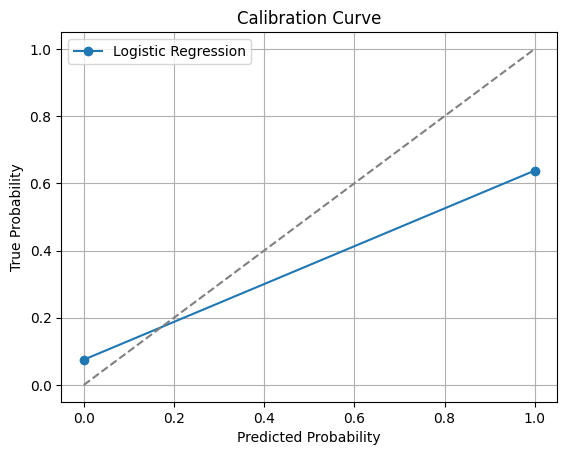

In [189]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test, lr_pred, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o', label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Predicted Probability')
plt.ylabel('True Probability')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()
